# Python vs Patch CNN Green Cover Performance


Annual mean green cover and matched months:

      Landsat CNN  Sentinel CNN  Landsat Python  Sentinel Python  \
year                                                               
2019        56.04         62.93           64.70            53.50   
2020        79.71         69.50           91.18            74.99   
2021        62.95         59.58           79.17            58.23   
2022        81.00         80.15           96.67            87.21   
2023        68.92         67.01           81.61            65.31   
2024        77.75         69.18           92.57            79.27   
2025        68.66         63.56           79.74            66.43   

      matched_months  
year                  
2019              12  
2020              10  
2021              12  
2022              11  
2023              12  
2024              12  
2025               8  


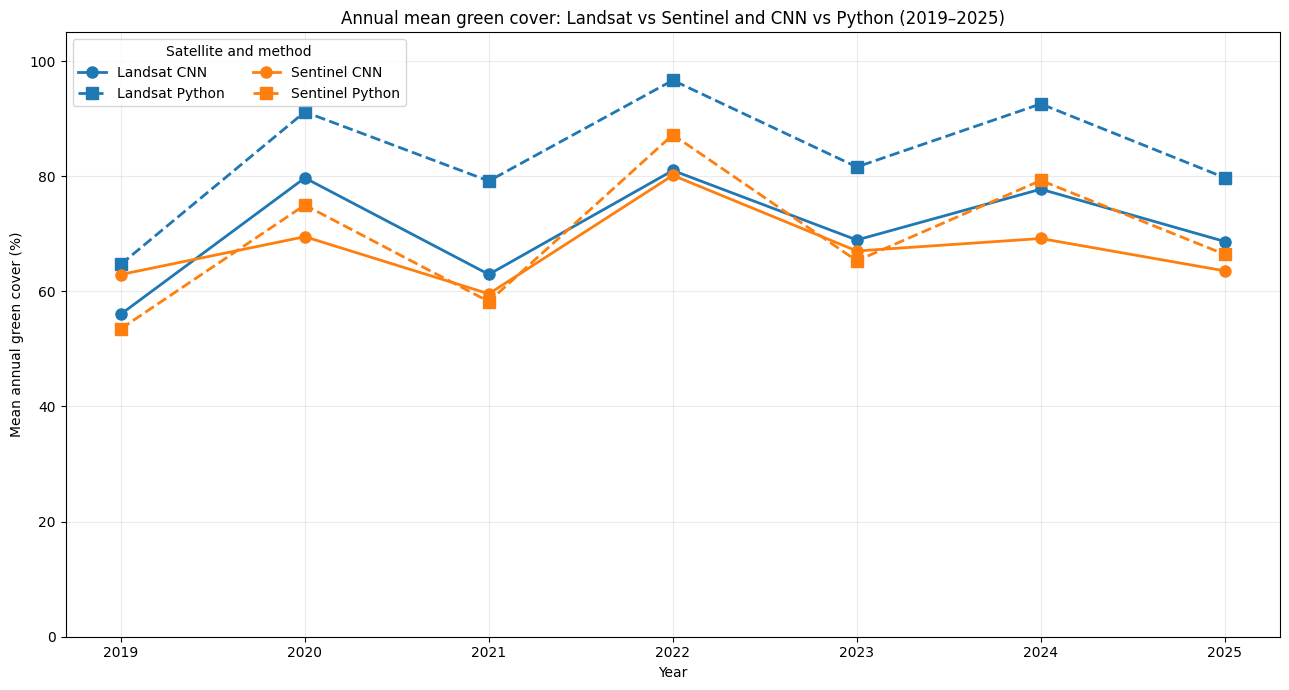

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#loading result files
landsat_cnn_file = "monthly_green_clean.csv"
sentinel_cnn_file = "monthly_green_clean_sent.csv"
python_file = "python_green_mask_results.csv"
landsat_cnn = pd.read_csv(landsat_cnn_file)
sentinel_cnn = pd.read_csv(sentinel_cnn_file)
python_results = pd.read_csv(python_file)

#prepare each monthly green cover series
#clean one result dataframe with monthly green indexed by date.
def prepare_green_series(dataframe,output_name,folder=None,):
    df = dataframe.copy()
    df["date"] = pd.to_datetime(
        df["date"],
        errors="coerce",)
    df["green_pct"] = pd.to_numeric(
        df["green_pct"],
        errors="coerce",)

    #used for the combined Python results file
    if folder is not None:
        df = df[df["folder"].eq(folder)]

    #keeps only images that passed quality screening
    df = df[df["use"].eq(True)]
    df = df.dropna(subset=["date","green_pct",])

    #prevents accidental duplicate months
    df = df.drop_duplicates(
        subset="date",
        keep="first",)
    return (df.set_index("date")["green_pct"].sort_index().rename(output_name))

landsat_cnn_series = prepare_green_series(landsat_cnn,output_name="Landsat CNN",)
sentinel_cnn_series = prepare_green_series(sentinel_cnn, output_name="Sentinel CNN",)
landsat_python_series = prepare_green_series(python_results, output_name="Landsat Python", folder="Landsat",)
sentinel_python_series = prepare_green_series(python_results, output_name="Sentinel Python", folder="Sentinel-2",)

#matching months across all four result series
monthly_comparison = pd.concat([landsat_cnn_series, sentinel_cnn_series, landsat_python_series, sentinel_python_series,],
    axis=1, join="inner",).sort_index()

#selecting some comparison years
start_year = 2019
end_year = 2025
monthly_comparison = monthly_comparison.loc[f"{start_year}-01-01":f"{end_year}-12-31"]

#calculate annual mean green cover
annual_green = (monthly_comparison.groupby(monthly_comparison.index.year).mean())
annual_green.index.name = "year"

#record the number of matched months used each year
months_used = (monthly_comparison.groupby(monthly_comparison.index.year).size().rename("matched_months"))
annual_summary = annual_green.join(months_used)
print("\nAnnual mean green cover and matched months:\n")
print(annual_summary.round(2))
#save the annual results
annual_summary.to_csv("annual_landsat_sentinel_method_comparison.csv")

#plotting annual averages
#colour to represent each satellite
#blue for Landsat, orange forSentinel
#marker represents method
#circle for CNN, square for Python

plot_styles = {"Landsat CNN": {"color": "tab:blue","marker": "o","linestyle": "-",},
    "Landsat Python": {"color": "tab:blue","marker": "s","linestyle": "--",},
    "Sentinel CNN": {"color": "tab:orange","marker": "o","linestyle": "-",},
    "Sentinel Python": {"color": "tab:orange","marker": "s","linestyle": "--",},}

fig, ax = plt.subplots(figsize=(13, 7))
for column, style in plot_styles.items():
    ax.plot(annual_green.index,annual_green[column],label=column,color=style["color"],
        marker=style["marker"],linestyle=style["linestyle"],linewidth=2,markersize=8,)


ax.set_xlabel("Year")
ax.set_ylabel("Mean annual green cover (%)")
ax.set_ylim(0,105,)
ax.set_xticks(annual_green.index)
ax.set_title("Annual mean green cover: " "Landsat vs Sentinel and CNN vs Python "f"({start_year}–{end_year})")
ax.grid(alpha=0.25)
ax.legend(title="Satellite and method",ncol=2,loc="best",)
fig.tight_layout()
plt.show()